Fitted  w=0.0481  b_a=5.5719  b_b=5.5572
Test ECE  before=0.28492  after=0.02319
Mean FD   before=1.60961  after=0.51584


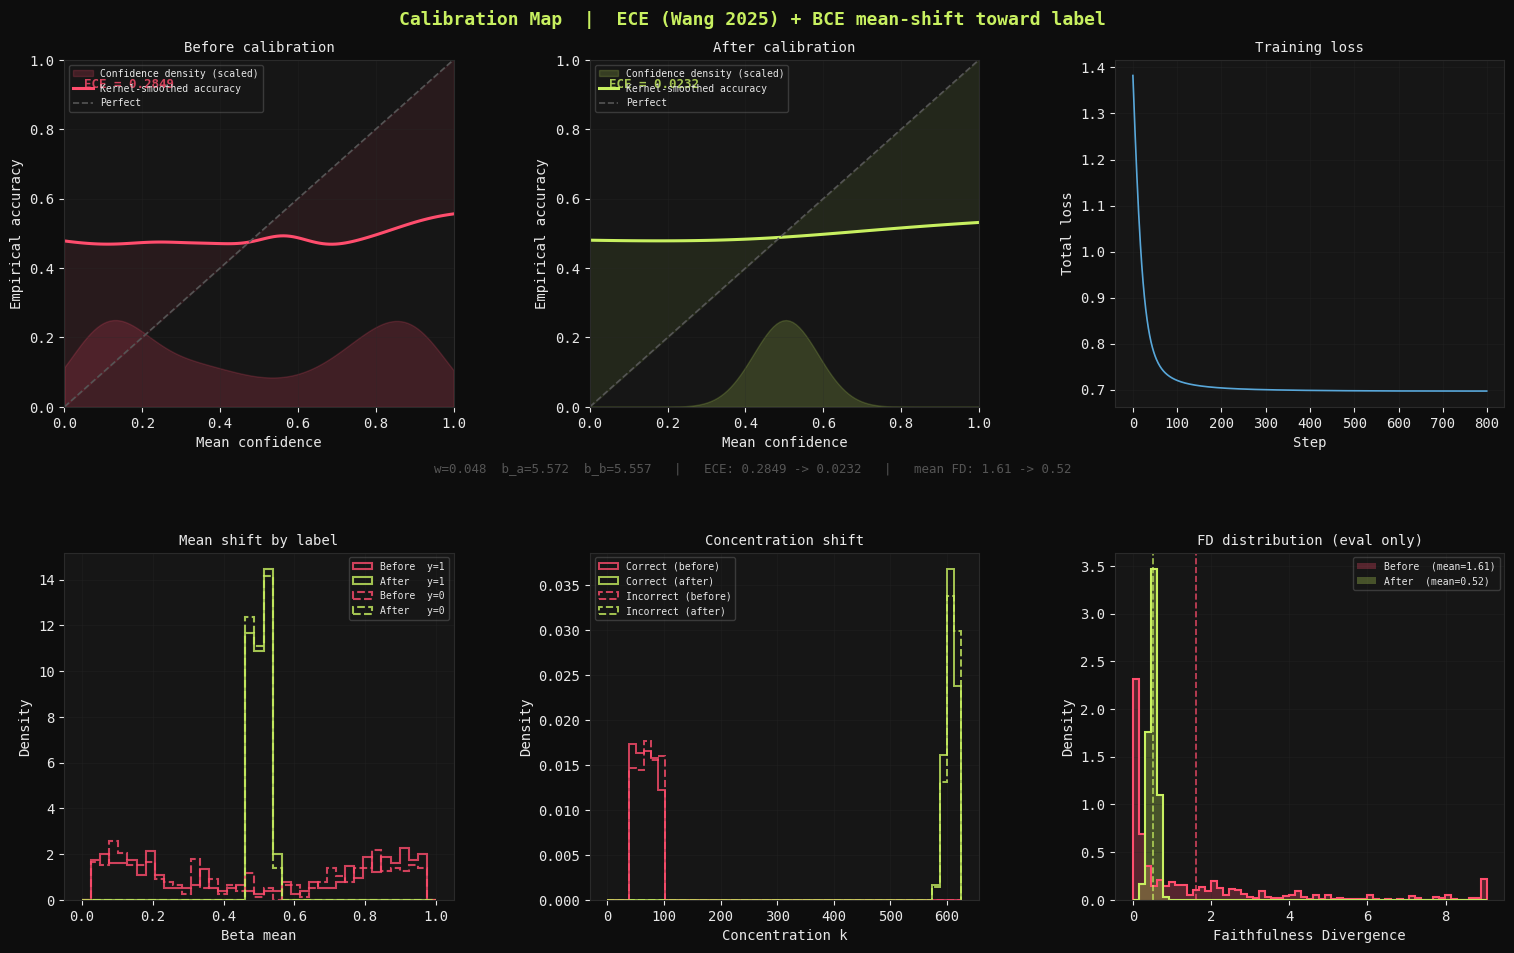

In [6]:
"""
Distributional Confidence Calibration Map
==========================================

Map (log-space affine, 3 parameters):
    log a' = w * log a + b_a
    log b' = w * log b + b_b

  w > 0 guarantees monotonicity of mu' in mu.
  Identity initialisation: w=1, b_a=0, b_b=0.

Loss:
    L = ECE_soft_sq + lambda * BCE(mu', y)

  ECE_soft_sq:  soft-binned squared ECE (Wang 2025), population level.
  BCE:          instance-level. Pulls mu' toward y (0 or 1) with gradient
                zero only at mu'=y. Log diverges as mu'->0 or 1, so
                the map is naturally prevented from collapsing to extremes.
                Strictly proper: population minimiser is P(y=1|x), not the
                hard label. Monotone pull guaranteed by convexity of BCE.

Eval metrics:
  ECE (L1, absolute, Wang soft-bin)
  FD  = (a+b) * KL( Beta_post || Beta_prior )   -- eval only, not in loss
"""

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc as scipy_betainc


# ════════════════════════════════════════════════════════════════════════════
# DIFFERENTIABLE BETA CDF
# forward : scipy (exact)
# backward: analytic grad wrt x; relative finite-diff wrt a and b
#           (relative eps handles large a, b stably)
# ════════════════════════════════════════════════════════════════════════════

class BetaIncFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, a, b, x):
        ctx.save_for_backward(a, b, x)
        return torch.from_numpy(
            scipy_betainc(a.detach().numpy(), b.detach().numpy(),
                          x.detach().numpy()).astype(np.float32))

    @staticmethod
    def backward(ctx, grad_output):
        a, b, x = ctx.saved_tensors

        # dI/dx = Beta pdf at x
        log_pdf = (
            (a - 1) * torch.log(x.clamp(1e-9))
            + (b - 1) * torch.log((1 - x).clamp(1e-9))
            - torch.lgamma(a) - torch.lgamma(b) + torch.lgamma(a + b)
        )
        grad_x = grad_output * torch.exp(log_pdf)

        # relative finite differences wrt a and b
        eps    = 1e-3
        a_np, b_np, x_np = a.numpy(), b.numpy(), x.numpy()
        da_h   = eps * np.maximum(np.abs(a_np), 1.0)
        db_h   = eps * np.maximum(np.abs(b_np), 1.0)

        da = torch.from_numpy(
            ((scipy_betainc(a_np + da_h, b_np, x_np)
              - scipy_betainc(a_np - da_h, b_np, x_np))
             / (2 * da_h)).astype(np.float32))
        db = torch.from_numpy(
            ((scipy_betainc(a_np, b_np + db_h, x_np)
              - scipy_betainc(a_np, b_np - db_h, x_np))
             / (2 * db_h)).astype(np.float32))

        return grad_output * da, grad_output * db, grad_x


def betainc(a, b, x):
    """Differentiable I_x(a, b). x is broadcast to shape of a."""
    return BetaIncFunc.apply(a, b, x.expand_as(a))


# ════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY
# ════════════════════════════════════════════════════════════════════════════

torch.manual_seed(42)
np.random.seed(42)


# ════════════════════════════════════════════════════════════════════════════
# 1. SYNTHETIC DATA
# Flat reliability curve, ECE ~ 0.30.
# Confidence bimodal at ~0.2 / ~0.8, labels independent -> flat accuracy ~0.5.
# ════════════════════════════════════════════════════════════════════════════

def generate_data(N=2000):
    alphas, betas, ys = [], [], []
    for _ in range(N):
        p_true = np.random.beta(2.0, 2.0)
        mu_model = (np.random.beta(1.5, 6.0) if np.random.rand() < 0.5
                    else np.random.beta(6.0, 1.5))
        mu_model = np.clip(mu_model, 0.05, 0.95)
        kap = np.random.uniform(40, 100)
        alphas.append(mu_model * kap)
        betas.append((1 - mu_model) * kap)
        ys.append(float(np.random.binomial(1, p_true)))
    return (np.array(alphas, np.float32),
            np.array(betas,  np.float32),
            np.array(ys,     np.float32))


alphas, betas, ys = generate_data(N=2000)
idx    = np.random.permutation(len(ys))
tr, te = idx[:1400], idx[1400:]

a_tr = torch.tensor(alphas[tr]); b_tr = torch.tensor(betas[tr]); y_tr = torch.tensor(ys[tr])
a_te = torch.tensor(alphas[te]); b_te = torch.tensor(betas[te]); y_te = torch.tensor(ys[te])


# ════════════════════════════════════════════════════════════════════════════
# 2. SOFT-BINNED ECE  (Wang 2025)
# ════════════════════════════════════════════════════════════════════════════

def _bin_weights(a, b, M, edges):
    """w[i,m] = P(S in I_m | Beta(a_i, b_i)),  shape [N, M]."""
    F_hi = betainc(
        a[:, None].expand(-1, M), b[:, None].expand(-1, M),
        edges[1:].clamp(1e-6, 1-1e-6).unsqueeze(0).expand(a.shape[0], -1))
    F_lo = betainc(
        a[:, None].expand(-1, M), b[:, None].expand(-1, M),
        edges[:-1].clamp(1e-6, 1-1e-6).unsqueeze(0).expand(a.shape[0], -1))
    return (F_hi - F_lo).clamp(min=0)


def soft_ece_sq(a, b, y, M=15):
    """Squared soft-binned ECE -- training objective (smooth gradients)."""
    edges = torch.linspace(0.0, 1.0, M + 1)
    mids  = 0.5 * (edges[1:] + edges[:-1])
    w     = _bin_weights(a, b, M, edges)
    r_m   = (w * y[:, None]).sum(0) / w.sum(0).clamp(1e-8)
    p_m   = w.mean(0)
    return (p_m * (r_m - mids).pow(2)).sum()


def soft_ece_abs(a, b, y, M=15):
    """Absolute soft-binned ECE (L1) -- reporting metric."""
    edges = torch.linspace(0.0, 1.0, M + 1)
    mids  = 0.5 * (edges[1:] + edges[:-1])
    w     = _bin_weights(a, b, M, edges)
    r_m   = (w * y[:, None]).sum(0) / w.sum(0).clamp(1e-8)
    p_m   = w.mean(0)
    return (p_m * (r_m - mids).abs()).sum()


# ════════════════════════════════════════════════════════════════════════════
# 3. MAP  (log-space affine, 3 parameters)
# ════════════════════════════════════════════════════════════════════════════

def apply_map(params, a, b):
    """
    log a' = w * log a + b_a
    log b' = w * log b + b_b

    w = softplus(w_raw) > 0  =>  mu' monotone increasing in mu.
    """
    w_raw, b_a, b_b = params
    w  = F.softplus(w_raw)
    a2 = torch.exp(w * torch.log(a.clamp(1e-6)) + b_a)
    b2 = torch.exp(w * torch.log(b.clamp(1e-6)) + b_b)
    return a2, b2, a2 / (a2 + b2), a2 + b2


# ════════════════════════════════════════════════════════════════════════════
# 4. LOSS
# ════════════════════════════════════════════════════════════════════════════

def bce_mean_shift(mu_p, y):
    """
    BCE: -[ y * log(mu') + (1-y) * log(1-mu') ]

    Pulls mu' toward label y monotonically.
    Log barrier prevents collapse to 0 or 1.
    Strictly proper: minimised at mu' = P(y=1 | x), not hard 0/1.
    """
    mu_c = mu_p.clamp(1e-6, 1 - 1e-6)
    return (-y * torch.log(mu_c) - (1 - y) * torch.log(1 - mu_c)).mean()


def total_loss(params, a, b, y, lam=1.0, M=15):
    a2, b2, mu_p, _ = apply_map(params, a, b)
    ece = soft_ece_sq(a2, b2, y, M=M)
    bce = bce_mean_shift(mu_p, y)
    return ece + lam * bce


# ════════════════════════════════════════════════════════════════════════════
# 5. TRAINING
# ════════════════════════════════════════════════════════════════════════════

params = [
    torch.tensor(1.0, requires_grad=True),   # w_raw
    torch.tensor(0.0, requires_grad=True),   # b_a
    torch.tensor(0.0, requires_grad=True),   # b_b
]

optimiser = torch.optim.Adam(params, lr=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=800)

losses = []
for step in range(800):
    optimiser.zero_grad()
    L = total_loss(params, a_tr, b_tr, y_tr, lam=1.0, M=15)
    L.backward()
    optimiser.step()
    scheduler.step()
    losses.append(L.item())

w_fit  = F.softplus(params[0]).item()
ba_fit = params[1].item()
bb_fit = params[2].item()
print(f"Fitted  w={w_fit:.4f}  b_a={ba_fit:.4f}  b_b={bb_fit:.4f}")


# ════════════════════════════════════════════════════════════════════════════
# 6. EVALUATION
# ════════════════════════════════════════════════════════════════════════════

with torch.no_grad():
    a2_te, b2_te, mu_p_te, kap_p_te = apply_map(params, a_te, b_te)

ece_before = soft_ece_abs(a_te,  b_te,  y_te).item()
ece_after  = soft_ece_abs(a2_te, b2_te, y_te).item()
print(f"Test ECE  before={ece_before:.5f}  after={ece_after:.5f}")


def beta_kl(a_p, b_p, a_q, b_q):
    """
    KL( Beta(a_p, b_p) || Beta(a_q, b_q) )  >= 0.

    Closed form:
        log B(a_q, b_q) - log B(a_p, b_p)
      + (a_p - a_q) * psi(a_p)
      + (b_p - b_q) * psi(b_p)
      + (a_q - a_p + b_q - b_p) * psi(a_p + b_p)

    P's parameters go into the digammas; Q's parameters only in log B(Q).
    """
    log_B_p = torch.lgamma(a_p) + torch.lgamma(b_p) - torch.lgamma(a_p + b_p)
    log_B_q = torch.lgamma(a_q) + torch.lgamma(b_q) - torch.lgamma(a_q + b_q)
    return (
          log_B_q - log_B_p
        + (a_p - a_q) * torch.digamma(a_p)
        + (b_p - b_q) * torch.digamma(b_p)
        + (a_q - a_p + b_q - b_p) * torch.digamma(a_p + b_p)
    )


def faithfulness_divergence(a, b, y):
    """
    FD_i = (a_i + b_i) * KL( Beta_post || Beta_prior )

    post  = Beta(a + y, b + 1 - y)
    prior = Beta(a, b)
    Always >= 0 by non-negativity of KL.
    """
    a_post = a + y
    b_post = b + (1 - y)
    kl = beta_kl(a_post, b_post, a, b)
    return (a + b) * kl


with torch.no_grad():
    fd_before = faithfulness_divergence(a_te,  b_te,  y_te)
    fd_after  = faithfulness_divergence(a2_te, b2_te, y_te)

fd_mean_before = fd_before.mean().item()
fd_mean_after  = fd_after.mean().item()
print(f"Mean FD   before={fd_mean_before:.5f}  after={fd_mean_after:.5f}")


# ════════════════════════════════════════════════════════════════════════════
# 7. RELIABILITY DATA
# ════════════════════════════════════════════════════════════════════════════

def reliability_data_kernel(a, b, y, n_grid=120, bandwidth=0.08):
    """Kernel-smoothed reliability curve over confidence mean."""
    mu = a / (a + b)
    grid = torch.linspace(0.0, 1.0, n_grid)

    # Gaussian kernel weights K_h(mu_i - g_j)
    diff = (mu[:, None] - grid[None, :]) / bandwidth
    k = torch.exp(-0.5 * diff.pow(2))

    denom = k.sum(0).clamp(min=1e-8)
    acc = (k * y[:, None]).sum(0) / denom
    density = denom / denom.sum().clamp(min=1e-8)
    return grid.numpy(), acc.numpy(), density.numpy()

with torch.no_grad():
    grid_b, acc_b, den_b = reliability_data_kernel(a_te,  b_te,  y_te)
    grid_a, acc_a, den_a = reliability_data_kernel(a2_te, b2_te, y_te)

mu_before  = (a_te / (a_te + b_te)).numpy()
mu_after   = mu_p_te.numpy()
kap_before = (a_te + b_te).numpy()
kap_after  = kap_p_te.numpy()
y_np       = y_te.numpy()


# ════════════════════════════════════════════════════════════════════════════
# 8. PLOTTING
# ════════════════════════════════════════════════════════════════════════════

DARK   = "#0d0d0d"; PANEL  = "#161616"; BORDER = "#2a2a2a"
ACCENT = "#c8f060"; RED    = "#ff4d6d"; BLUE   = "#60b8f0"
MUTED  = "#555555"; WHITE  = "#e8e8e8"

plt.rcParams.update({
    "figure.facecolor": DARK,   "axes.facecolor":  PANEL,
    "axes.edgecolor":   BORDER, "axes.labelcolor": WHITE,
    "xtick.color":      WHITE,  "ytick.color":     WHITE,
    "text.color":       WHITE,  "grid.color":      BORDER,
    "grid.linewidth":   0.6,    "font.family":     "monospace",
    "font.size":        10,
})

fig = plt.figure(figsize=(16, 10), facecolor=DARK)
fig.suptitle(
    "Calibration Map  |  ECE (Wang 2025) + BCE mean-shift toward label",
    fontsize=13, color=ACCENT, y=0.97, fontfamily="monospace", fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                       left=0.07, right=0.97, top=0.92, bottom=0.08)


def plot_reliability(ax, grid, acc, density, title, ece_val, colour):
    den_scaled = density / density.max().clip(min=1e-8) * 0.25
    ax.fill_between(grid, 0.0, den_scaled, color=colour, alpha=0.18, label="Confidence density (scaled)")
    ax.plot(grid, acc, color=colour, lw=2.2, label="Kernel-smoothed accuracy")
    ax.plot([0, 1], [0, 1], "--", color=MUTED, lw=1.2, label="Perfect")
    ax.fill_between(grid, grid, acc, color=colour, alpha=0.08)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title(title, color=WHITE, fontsize=10)
    ax.text(0.05, 0.92, f"ECE = {ece_val:.4f}", transform=ax.transAxes,
            color=colour, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, framealpha=0.2)
    ax.grid(True, alpha=0.3)


ax0 = fig.add_subplot(gs[0, 0])
plot_reliability(ax0, grid_b, acc_b, den_b, "Before calibration", ece_before, RED)

ax1 = fig.add_subplot(gs[0, 1])
plot_reliability(ax1, grid_a, acc_a, den_a, "After calibration",  ece_after,  ACCENT)

ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(losses, color=BLUE, lw=1.2, alpha=0.9)
ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss")
ax2.set_title("Training loss", color=WHITE, fontsize=10)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
bins_mu = np.linspace(0, 1, 40)
for label, arr, col, ls in [
    ("Before  y=1", mu_before[y_np == 1], RED,    "-"),
    ("After   y=1", mu_after [y_np == 1], ACCENT, "-"),
    ("Before  y=0", mu_before[y_np == 0], RED,    "--"),
    ("After   y=0", mu_after [y_np == 0], ACCENT, "--"),
]:
    ax3.hist(arr, bins=bins_mu, density=True, histtype="step",
             color=col, linestyle=ls, lw=1.5, label=label, alpha=0.8)
ax3.set_xlabel("Beta mean"); ax3.set_ylabel("Density")
ax3.set_title("Mean shift by label", color=WHITE, fontsize=10)
ax3.legend(fontsize=7, framealpha=0.2)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
kap_max = np.percentile(np.concatenate([kap_before, kap_after]), 98)
bins_k  = np.linspace(0, kap_max, 50)
correct   = ((y_np == 1) & (mu_after > 0.5)) | ((y_np == 0) & (mu_after < 0.5))
incorrect = ~correct
for label, mask, col in [
    ("Correct (before)",   correct,   RED),
    ("Correct (after)",    correct,   ACCENT),
    ("Incorrect (before)", incorrect, RED),
    ("Incorrect (after)",  incorrect, ACCENT),
]:
    arr = kap_before if "before" in label else kap_after
    ax4.hist(arr[mask], bins=bins_k, density=True, histtype="step",
             color=col, linestyle="-" if "Correct" in label else "--",
             lw=1.4, label=label, alpha=0.8)
ax4.set_xlabel("Concentration k"); ax4.set_ylabel("Density")
ax4.set_title("Concentration shift", color=WHITE, fontsize=10)
ax4.legend(fontsize=7, framealpha=0.2)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
fd_b_np = fd_before.numpy()
fd_a_np = fd_after.numpy()
p99     = np.percentile(np.concatenate([fd_b_np, fd_a_np]), 99)
bins_fd = np.linspace(0, p99, 60)
for fd_np, col, prefix in [(fd_b_np, RED, "Before"), (fd_a_np, ACCENT, "After")]:
    mv = fd_np.mean()
    ax5.hist(fd_np.clip(0, p99), bins=bins_fd, density=True,
             histtype="stepfilled", color=col, alpha=0.28,
             label=f"{prefix}  (mean={mv:.2f})")
    ax5.hist(fd_np.clip(0, p99), bins=bins_fd, density=True,
             histtype="step", color=col, lw=1.5)
    ax5.axvline(mv, color=col, lw=1.2, linestyle="--", alpha=0.8)
ax5.set_xlabel("Faithfulness Divergence"); ax5.set_ylabel("Density")
ax5.set_title("FD distribution (eval only)", color=WHITE, fontsize=10)
ax5.legend(fontsize=7, framealpha=0.2)
ax5.grid(True, alpha=0.3)

fig.text(
    0.50, 0.505,
    f"w={w_fit:.3f}  b_a={ba_fit:.3f}  b_b={bb_fit:.3f}"
    f"   |   ECE: {ece_before:.4f} -> {ece_after:.4f}"
    f"   |   mean FD: {fd_mean_before:.2f} -> {fd_mean_after:.2f}",
    ha="center", va="bottom", color=MUTED, fontsize=9, fontfamily="monospace"
)

# plt.savefig("/mnt/user-data/outputs/calibration_results.png",
#             dpi=150, bbox_inches="tight", facecolor=DARK)
# plt.close()
# print("Saved calibration_results.png")
plt.show()